# 🌍 TravelMind :

**Project:** Domain-Specific QA Chatbot for Travel & Tourism  
**Dataset:** travel-QA
**Approach:** RAG (Retrieval-Augmented Generation) + Groq LLM  

---
## STEP 1 — Install All Libraries

In [ ]:
!pip install -q datasets
!pip install -q sentence-transformers
!pip install -q faiss-cpu
!pip install -q groq
!pip install -q gradio
!pip install -q rouge-score
!pip install -q bert-score
!pip install -q transformers

print('✅ All libraries installed!')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 46.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 141.7/141.7 kB 5.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 1.8 MB/s eta 0:00:00
✅ All libraries installed!


## STEP 2 — Imports

In [ ]:
import pandas as pd
import numpy as np
import json
import shutil
from datasets import load_dataset

print('✅ Imports done!')

✅ Imports done!


## STEP 3 — Load Travel-QA


In [ ]:
print('Loading Travel QA dataset...')

dataset = load_dataset("JasleenSingh91/travel-QA", split="train")

print(f'✅ Loaded {len(dataset)} records')
print(f'Columns: {dataset.column_names}')

Loading Travel QA dataset...
✅ Loaded 17672 records
Columns: ['Question', 'Response']


---
## STEP 4 — Extract Clean Questions & Answers

Truncate answers to 300 characters — this keeps embeddings focused and the FAISS search efficient

In [ ]:
print('Processing dataset...')

df = dataset.to_pandas()

# Rename columns
df = df.rename(columns={
    'Question': 'question',
    'Response': 'answer'
})
# Drop nulls
df = df.dropna()

# Keep reasonable answers (LESS strict)
df = df[
    (df['answer'].str.len() > 10) &
    (df['answer'].str.len() < 1300)
].reset_index(drop=True)
df['answer'] = df['answer'].str.slice(0, 300)
print("After cleaning:", len(df))


print("\nSample:")
print("Q:", df['question'][0])
print("A:", df['answer'][0])

Processing dataset...
After cleaning: 5080

Sample:
Q: Suggest winter destinations with snow activities and cozy settings.
A: Looking for that perfect snowy escape with cozy vibes? Here are some dreamy winter destinations where you can dive into snow-filled fun and then snuggle up in warmth:

In the U.S.
Aspen, Colorado
Picture this: pristine slopes for skiing and snowboarding by day, and cozy nights by the fire in a charm


---
## STEP 5 — Quick Data Check

Always look at your data before saving it.

In [ ]:
print('=== Dataset Statistics ===')
print(f'Total QA pairs        : {len(df)}')
print(f'Avg question length   : {df["question"].str.len().mean():.0f} chars')
print(f'Avg answer length     : {df["answer"].str.len().mean():.0f} chars')
print()

print('=== 3 Random Examples ===')
for _, row in df.sample(min(3, len(df)), random_state=42).iterrows():
    print(f'Q: {row["question"]}')
    print(f'A: {row["answer"][:200]}...')
    print('-' * 60)

=== Dataset Statistics ===
Total QA pairs        : 5080
Avg question length   : 83 chars
Avg answer length     : 300 chars

=== 3 Random Examples ===
Q: Suggest a winter destination focused on relaxation with cozy lodges, spas, and serene landscapes.
A: 
    I would suggest Jackson Hole, Wyoming, as a winter destination focused on relaxation. This beautiful location offers a peaceful and serene setting with cozy lodges, spas, and stunning landscapes....
------------------------------------------------------------
Q: How do I organize a group tour to the Greek Islands for 10 people?
A: 
    1. Choose the Islands: Decide which Greek Islands you would like to visit. Popular choices include Mykonos, Santorini, Crete, and Rhodes.
    2. Choose the Duration: Determine the length of your ...
------------------------------------------------------------
Q: Suggest family-friendly vacation spots in Africa offering cultural immersion experiences like village tours, markets, and festivals.
A: abso

---
## STEP 6 — Create Document Format for RAG

Each document = Question + Answer combined as one text chunk.  

1) This is the most important line conceptually. You combine the question and answer into one text chunk called a document. This is what gets embedded and stored in FAISS later — the idea is that a user's query should semantically match these combined chunks.

2) From the full cleaned dataset, you randomly sample 1500 rows. This is your knowledge base — the set of documents that your chatbot can retrieve from. Using a sample keeps the system fast without sacrificing quality.

3) The quality of the RAG system is directly tied to this phase. If you feed messy, too-short, or too-long text into the embeddings model, the retrieval quality drops. By cleaning aggressively and combining Q+A into one chunk, you ensure that when a user asks "best time to visit Thailand", the FAISS search finds a document that contains both the question context and the answer, giving the LLM richer information to work with.



In [ ]:
# Combine Q + A (clean format for embeddings)
df['document'] = df['question'] + " " + df['answer']

# Sample for RAG (important for speed)
df_rag = df.sample(1500, random_state=42).reset_index(drop=True)

print(f'Full dataset  : {len(df)} QA pairs')
print(f'RAG KB size   : {len(df_rag)} documents')

print('\nSample document:')
print('=' * 60)
print(df_rag['document'][0])
print('=' * 60)

Full dataset  : 5080 QA pairs
RAG KB size   : 1500 documents

Sample document:
Suggest a winter destination focused on relaxation with cozy lodges, spas, and serene landscapes. 
    I would suggest Jackson Hole, Wyoming, as a winter destination focused on relaxation. This beautiful location offers a peaceful and serene setting with cozy lodges, spas, and stunning landscapes.
    Jackson Hole is located at the base of the spectacular Tetons, providing breathtaking views and


---
## STEP 7 — Save Files

We save 3 files and back them up to Google Drive.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Save locally
df.to_csv('/content/travel_qa_clean.csv', index=False)
df_rag.to_csv('/content/travel_qa_rag.csv', index=False)

documents = df_rag['document'].tolist()

with open('/content/travel_qa_rag.json', 'w', encoding='utf-8') as f:
    json.dump(documents, f, ensure_ascii=False, indent=2)

# Backup to Drive
for fname in ['travel_qa_clean.csv', 'travel_qa_rag.csv', 'travel_qa_rag.json']:
    shutil.copy(f'/content/{fname}', f'/content/drive/MyDrive/{fname}')
    print(f'✅ Saved {fname}')

print('\nAll files saved to Google Drive!')

Mounted at /content/drive
✅ Saved travel_qa_clean.csv
✅ Saved travel_qa_rag.csv
✅ Saved travel_qa_rag.json

All files saved to Google Drive!


**PHASE 2**
Phase 1 gave you clean text. Phase 2 answers: how do you search through  documents meaningfully? Not by keyword matching — by meaning. You convert every document into a vector (a list of numbers that captures semantic meaning), then build a searchable index from those vectors using FAISS.


In [ ]:
from sentence_transformers import SentenceTransformer
import faiss
import numpy as np

print("✅ Libraries loaded")

✅ Libraries loaded


all-mpnet-base-v2 is a **pretrained model from the sentence-transformers library. It takes a piece of text and outputs a 768-dimensional vector — 768 numbers that together represent the meaning of that text**. It's one of the best general-purpose embedding models available.(you're not training anything here. This model is already trained on massive amounts of text. You're just using it as a tool to convert your documents into vectors.)


In [ ]:
print("Loading embedding model...")

model = SentenceTransformer('all-mpnet-base-v2')

print("✅ Model loaded")

Loading embedding model...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

✅ Model loaded


**Every one of your 1500 documents gets passed through the model and comes out as a 768-number vector**. So the final embeddings matrix is shaped (1500, 768) — 1500 rows, 768 columns.
The .astype('float32') conversion is required because FAISS only works with 32-bit floats.

In [ ]:
print("Creating embeddings...")

documents = df_rag['document'].tolist()

embeddings = model.encode(
    documents,
    show_progress_bar=True
)

embeddings = np.array(embeddings).astype('float32')


print("✅ Embeddings created:", embeddings.shape)

Creating embeddings...


Batches:   0%|          | 0/47 [00:00<?, ?it/s]

✅ Embeddings created: (1500, 768)


# FAISS = A Special Database for Vectors
A normal database (like SQL) stores text/numbers and searches by exact matching or filtering — "find all rows where city = 'Paris'".
FAISS stores vectors and searches by similarity — "find the 3 vectors most similar to this query vector."

# (Facebook AI Similarity Search)

IndexFlatL2 is the simplest index type — it does an exact brute-force search using Euclidean (L2) distance between vectors. Two vectors that are close in L2 distance = two pieces of text with similar meaning.
index.add(embeddings) loads all 1500 vectors into the index. Now it's ready to search.

In [ ]:
dimension = embeddings.shape[1]

index = faiss.IndexFlatL2(dimension)

index.add(embeddings)

print("✅ FAISS index built")
print("Total vectors:", index.ntotal)

✅ FAISS index built
Total vectors: 1500


This is the core search logic. When a user types a query:

The query is encoded into a vector using the same model
FAISS finds the k=3 closest vectors in the index (by L2 distance)
You look up those indices in df_rag and return the matching Q&A pairs

This is why using the same model matters — the query vector and document vectors live in the same vector space, so distances are meaningful.

In [ ]:
def retrieve(query, k=3):
    query_vec = model.encode([query]).astype('float32')

    distances, indices = index.search(query_vec, k)

    results = []

    for i in indices[0]:
        results.append({
            "question": df_rag.iloc[i]['question'],
            "answer": df_rag.iloc[i]['answer']
        })

    return results

In [ ]:
# query = "recommend places with a good beach"
# query = "best places in assam"
query = "best places to visit in india"

results = retrieve(query, k=3)

for i, r in enumerate(results):
    print(f"\nResult {i+1}:")
    print("Q:", r['question'])
    print("A:", r['answer'][:150])


Result 1:
Q: Suggest a destination that offers a unique cultural experience and natural beauty, like Vietnam, Peru, or Morocco.
A: 
    One destination that has a rich cultural experience and stunning natural beauty is India. India is known for its ancient history, vibrant festiva

Result 2:
Q: Recommend a destination with rich cultural heritage, scenic beauty, and adventure opportunities.
A: 
    I would recommend the beautiful country of India for your travels. India offers a rich cultural heritage with its ancient temples, historic monum

Result 3:
Q: Suggest a destination for a unique cultural experience combined with outdoor adventures.
A: 
    I would recommend exploration of the stunning and culturally rich destination of Bhutan. Known as the Land of the Thunder Dragon, Bhutan is a tin


Why RAG at all? Why not just use the LLM directly?
If you ask the LLM "best budget hotels in Tbilisi?" directly with no context, it might hallucinate — confidently give you wrong or outdated information from its training data.
RAG fixes this by saying: "Here are 3 relevant documents from our knowledge base. Now answer the question using ONLY this." The LLM becomes a reader and summarizer, not a guesser.

In [7]:
import os
from google.colab import userdata
os.environ["GROQ_API_KEY"] = userdata.get("GROQ_API_KEY")

In [8]:
import os
!pip install -q groq # Re-install groq as it was removed
from groq import Groq

# Directly pass your Groq API key.
# For production, consider using Colab's 'Secrets' feature for security.
client = Groq(api_key=os.environ.get("GROQ_API_KEY"))

In [ ]:
def retrieve_context(query, k=3):
    query_vec = model.encode([query]).astype('float32')

    distances, indices = index.search(query_vec, k)

    contexts = []

    for i in indices[0]:
        contexts.append(df_rag.iloc[i]['document'])

    return "\n\n".join(contexts)

This is prompt engineering — structuring the input to the LLM carefully. Three things are happening here:

You give the model a role ("you are a helpful travel assistant") — this sets its tone and behavior
You provide the retrieved context — the 3 documents from FAISS
You ask the user's question at the end

In [ ]:
def build_prompt(query, context):
    prompt = f"""
You are a helpful travel assistant.

Answer the question using the context below.
If you cant do so, say you dont know , its not in dataset, dont try to make up an answer.

Context:
{context}

Question:
{query}

Answer:
"""
    return prompt

This is the final assembled pipeline. For every user query:

retrieve_context() → hits FAISS → gets 3 relevant documents
build_prompt() → wraps them into a structured prompt
client.chat.completions.create() → sends prompt to Llama 3.1 8B running on Groq's API
Returns the LLM's generated answer

Why Groq? Groq provides extremely fast LLM inference — much faster than running a model locally. llama-3.1-8b-instant is a lightweight but capable open-source model, good for Q&A tasks.
temperature=0.3 — keeps the output focused and factual. Lower temperature = less creativity, more consistency. For a travel assistant, you don't want the model improvising.

In [ ]:
def ask_bot(query):
    context = retrieve_context(query, k=3)

    prompt = build_prompt(query, context)

    response = client.chat.completions.create(
        model="llama-3.1-8b-instant",   # ✅ NEW WORKING MODEL
        messages=[{"role": "user", "content": prompt}],
        temperature=0.3
    )

    return response.choices[0].message.content

In [ ]:
print(ask_bot("Best time to visit Thailand"))
print(ask_bot("Cheap hotels in Paris"))
print(ask_bot("Visa requirements for France"))
print(ask_bot("Weather in Dubai in summer"))

Based on the context, I would recommend visiting Thailand during the dry season, which typically runs from November to March. This is considered the best time to visit Thailand as the weather is generally dry and cool, making it ideal for outdoor activities and cultural exploration.
To find affordable hotels in Paris during the high tourist season, consider the following options:

1. Stay in an area that's a bit farther from the major tourist sites, such as Montmartre or the 12th arrondissement. These areas offer more budget-friendly hotels and hostels.
2. Check hotel discount websites like Booking.com, Expedia, and Hotels.com for deals and discounts.

Some budget-friendly hotels in Paris include:
1. Hôtel Des Abbesses: Located in Montmartre, a short walk from the Sacré-Cœur Basilica and the Moulin Rouge. Prices start from around [price not specified].
I don't know, it's not in the dataset.
I don't know, it's not in the dataset.


In [ ]:
print(ask_bot("Best places in meghalaya"))

I don't know, it's not in the dataset.


### User Interface (Gradio)

In [ ]:
import gradio as gr

# Create the Gradio interface
iface = gr.Interface(
    fn=ask_bot,
    inputs=gr.Textbox(lines=2, placeholder="Ask me a travel question..."),
    outputs="text",
    title="🌍 TravelMind Chatbot (Groq + RAG)",
    description="Ask any question about travel, and I'll do my best to provide information from my knowledge base."
)

# Launch the interface
iface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://0ec1c2b21ce4763990.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
!pip install -q unsloth trl datasets accelerate torch
# No need to restart runtime unless it crashes, but recommended if you just had errors.

In [ ]:
from unsloth import FastLanguageModel
import torch
from datasets import Dataset, load_dataset

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = "unsloth/tinyllama", # Much more stable for T4
    max_seq_length = 2048,
    load_in_4bit = True,
)

model = FastLanguageModel.get_peft_model(
    model,
    r = 16,
    target_modules = ["q_proj", "k_proj", "v_proj", "o_proj",
                      "gate_proj", "up_proj", "down_proj"],
    lora_alpha = 16,
    lora_dropout = 0,
    bias = "none",
)

==((====))==  Unsloth 2026.4.5: Fast Llama patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Unsloth: Will load unsloth/tinyllama-bnb-4bit as a legacy tokenizer.


In [ ]:
raw = load_dataset("JasleenSingh91/travel-QA", split="train")
df = raw.to_pandas()
df = df.rename(columns={"Question": "question", "Response": "answer"}).dropna()
df = df[(df["answer"].str.len() > 50) & (df["answer"].str.len() < 500)]
df_train = df.sample(n=min(1000, len(df)), random_state=42)

def format_tiny(row):
    # TinyLlama handles ChatML/Alpaca style well
    return {"text": f"### Instruction:\nTravel Assistant\n\n### Question:\n{row['question']}\n\n### Answer:\n{row['answer']}</s>"}

dataset = Dataset.from_list(df_train.apply(format_tiny, axis=1).tolist())

In [ ]:
from trl import SFTTrainer
from transformers import TrainingArguments

# TinyLlama needs a padding token defined to avoid 0 loss
tokenizer.pad_token = tokenizer.eos_token

trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    train_dataset = dataset,
    dataset_text_field = "text",
    max_seq_length = 2048,
    args = TrainingArguments(
        per_device_train_batch_size = 4,
        gradient_accumulation_steps = 4,
        warmup_steps = 10,
        max_steps = 100, # Increased steps for a smaller model
        learning_rate = 2e-4,
        fp16 = True,     # Works perfectly with TinyLlama on T4
        bf16 = False,
        logging_steps = 1,
        optim = "adamw_8bit",
        weight_decay = 0.01,
        lr_scheduler_type = "linear",
        seed = 3407,
        output_dir = "outputs",
    ),
)

trainer.train()

Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/373 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'pad_token_id': 2}.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 373 | Num Epochs = 5 | Total steps = 100
O^O/ \_/ \    Batch size per device = 4 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (4 x 4 x 1) = 16
 "-____-"     Trainable parameters = 12,615,680 of 1,112,664,064 (1.13% trained)


Step,Training Loss
1,2.039783
2,2.080854
3,2.058460
4,2.026031
5,2.057889
6,1.937895
7,2.035683
8,2.033517
9,1.959447
10,1.978351


TrainOutput(global_step=100, training_loss=2.0416949021816255, metrics={'train_runtime': 117.6091, 'train_samples_per_second': 13.604, 'train_steps_per_second': 0.85, 'total_flos': 1612535333437440.0, 'train_loss': 2.0416949021816255, 'epoch': 4.170212765957447})

In [ ]:
logs = trainer.state.log_history

steps = []
losses = []

for log in logs:
    if "loss" in log:
        steps.append(log["step"])
        losses.append(log["loss"])

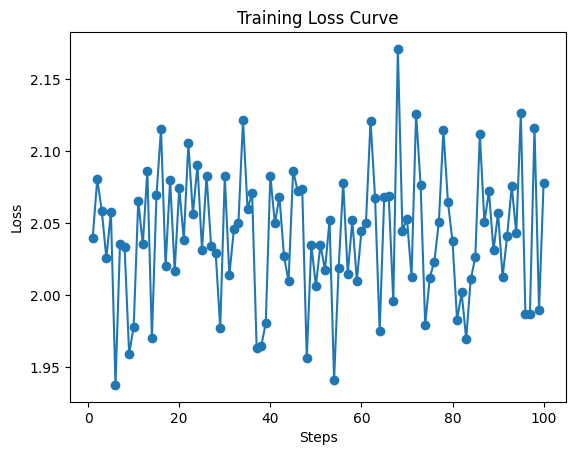

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(steps, losses, marker='o')
plt.xlabel("Steps")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.show()

In [ ]:
FastLanguageModel.for_inference(model)

def ask_bot(query):
    prompt = f"### Instruction:\nTravel Assistant\n\n### Question:\n{query}\n\n### Answer:\n"
    inputs = tokenizer(prompt, return_tensors="pt").to("cuda")

    outputs = model.generate(
        **inputs,
        max_new_tokens=150,
        repetition_penalty=1.2,
        temperature=0.7,
        do_sample=True
    )
    return tokenizer.decode(outputs[0], skip_special_tokens=True).split("### Answer:")[-1].strip()

print(ask_bot("What are the top 3 things to do in Tokyo?"))

Both `max_new_tokens` (=150) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)


Tokyo is home to one of our world-class theme parks, so why not check out Universal Studios Japan! This theme park houses attractions inspired by characters and stories from some of your favorite movies. We love seeing them at work as they create lifelike scenes right before our eyes. If you're looking for a bit more excitement after you explore the parks over there, head into Shibuya or Asakusa, two very busy areas that have lots going on! They offer a wide variety of restaurants, shops, and cafes—everything you need to enjoy a relaxing day filled with fun. For an alternative nightlife experience, visit Shinjuku Golden…

###


In [ ]:
print(ask_bot("what season to visit bangkok"))

Both `max_new_tokens` (=150) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


The best time for you is the

**Season:** Spring

**Situation** :
The weather is good during spring.  During this period, it's hot in
Bangkok (average temperature from 20-35°c) but not as hot as other times of
the year . The weather cools down a little bit when night falls and the air gets
still cooler than at daytime temperatures. So, if you don't have too much sun
and stay outdoors only around noon or so on one side, then there shouldn't be any problem with your health while staying here all summer long!


In [ ]:
import gradio as gr

def chat_with_bot(message, history):
    prompt = f"### Instruction:\nTravel Assistant\n\n### Question:\n{message}\n\n### Answer:\n"
    inputs = tokenizer(prompt, return_tensors="pt").to("cuda")

    outputs = model.generate(
        **inputs,
        max_new_tokens=512,        # 👈 Increased from 256
        repetition_penalty=1.2,
        temperature=0.7,
        do_sample=True,
        eos_token_id=tokenizer.eos_token_id,
        pad_token_id=tokenizer.pad_token_id # 👈 Helps avoid mid-sentence cuts
    )

    full_text = tokenizer.decode(outputs[0], skip_special_tokens=True)
    response = full_text.split("### Answer:")[-1].strip()

    # Optional: If it still ends without a period, trim the last broken sentence
    if response and response[-1] not in [".", "!", "?"]:
        last_punctuation = max(response.rfind("."), response.rfind("!"), response.rfind("?"))
        if last_punctuation != -1:
            response = response[:last_punctuation + 1]

    return response

# Build the UI
demo = gr.ChatInterface(
    fn=chat_with_bot,
    title="🌍 AI Travel Assistant",
    description="Ask me about flights, hotels, or hidden gems in any city!",
    examples=["Best time to visit Bali?", "3-day itinerary for Tokyo", "Budget hotels in Paris"],
    theme="soft"
)

# Launch with a shareable link
demo.launch(share=True)

/usr/local/lib/python3.12/dist-packages/gradio/chat_interface.py:347: UserWarning: The 'tuples' format for chatbot messages is deprecated and will be removed in a future version of Gradio. Please set type='messages' instead, which uses openai-style 'role' and 'content' keys.
  self.chatbot = Chatbot(


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://019d80e5313a2fabf1.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
print(ask_bot("Best time to visit Thailand"))
print("-----")
print(ask_bot("Cheap hotels in Paris"))